In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/tthien/shanghaitech-with-people-density-map/shanghaitech_with_people_density_map/ShanghaiTech/part_B/test_data/ground-truth-h5/IMG_79.h5
/kaggle/input/datasets/tthien/shanghaitech-with-people-density-map/shanghaitech_with_people_density_map/ShanghaiTech/part_B/test_data/ground-truth-h5/IMG_123.h5
/kaggle/input/datasets/tthien/shanghaitech-with-people-density-map/shanghaitech_with_people_density_map/ShanghaiTech/part_B/test_data/ground-truth-h5/IMG_266.h5
/kaggle/input/datasets/tthien/shanghaitech-with-people-density-map/shanghaitech_with_people_density_map/ShanghaiTech/part_B/test_data/ground-truth-h5/IMG_203.h5
/kaggle/input/datasets/tthien/shanghaitech-with-people-density-map/shanghaitech_with_people_density_map/ShanghaiTech/part_B/test_data/ground-truth-h5/IMG_18.h5
/kaggle/input/datasets/tthien/shanghaitech-with-people-density-map/shanghaitech_with_people_density_map/ShanghaiTech/part_B/test_data/ground-truth-h5/IMG_259.h5
/kaggle/input/datasets/tthien/shangh

In [3]:
!git clone https://github.com/arzoovaswani415/Crowd_density_estimation.git

Cloning into 'Crowd_density_estimation'...
remote: Enumerating objects: 1638, done.
remote: Counting objects: 100% (33/33), done.
remote: Compressing objects: 100% (31/31), done.
remote: Total 1638 (delta 14), reused 6 (delta 2), pack-reused 1605 (from 2)
Receiving objects: 100% (1638/1638), 832.10 MiB | 22.58 MiB/s, done.
Resolving deltas: 100% (122/122), done.


In [4]:
!ls /kaggle/working/Crowd_density_estimation/src

 best_model.pth     csrnet.py		       deform_block.py	 __pycache__
 cnn.py		    dataset.py		       __init__.py
 csrnet_deform.py  'deform_attention (2).py'   mcnn.py


In [6]:
import sys
sys.path.append("/kaggle/working/Crowd_density_estimation")

In [7]:
from src.dataset import ShanghaiTechDataset
from src.csrnet import CSRNet

print("✅ Import successful")

✅ Import successful


In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CSRNet().to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-5)

In [13]:
train_img_dir = "/kaggle/input/datasets/tthien/shanghaitech-with-people-density-map/ShanghaiTech/part_B/train_data/images"
train_gt_dir  = "/kaggle/input/datasets/tthien/shanghaitech-with-people-density-map/ShanghaiTech/part_B/train_data/ground-truth-h5"

test_img_dir = "/kaggle/input/datasets/tthien/shanghaitech-with-people-density-map/ShanghaiTech/part_B/test_data/images"
test_gt_dir  = "/kaggle/input/datasets/tthien/shanghaitech-with-people-density-map/ShanghaiTech/part_B/test_data/ground-truth-h5"

In [14]:
train_dataset = ShanghaiTechDataset(train_img_dir, train_gt_dir, resize=(256,256))
test_dataset  = ShanghaiTechDataset(test_img_dir, test_gt_dir, resize=(256,256))

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=1, shuffle=False)

Total valid samples: 400
Total valid samples: 316


In [18]:
num_epochs = 20
train_losses = []

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0
    
    for images, density_maps in train_loader:
        images = images.to(device)
        density_maps = density_maps.to(device)

        optimizer.zero_grad()
        outputs = model(images)

        # 🔥 Resize GT to match output
        scale = density_maps.shape[2] / outputs.shape[2]

        density_maps_resized = F.interpolate(
            density_maps,
            size=outputs.shape[2:],
            mode='bilinear',
            align_corners=False
        ) * (scale * scale)

        loss = criterion(outputs, density_maps_resized)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    epoch_loss /= len(train_loader)
    train_losses.append(epoch_loss)

    print(f"Epoch [{epoch+1}/{num_epochs}] Loss: {epoch_loss:.6f}")

Epoch [1/20] Loss: 0.438995
Epoch [2/20] Loss: 0.418087
Epoch [3/20] Loss: 0.417891
Epoch [4/20] Loss: 0.417115
Epoch [5/20] Loss: 0.416445
Epoch [6/20] Loss: 0.413249
Epoch [7/20] Loss: 0.412557
Epoch [8/20] Loss: 0.400739
Epoch [9/20] Loss: 0.395882
Epoch [10/20] Loss: 0.382689
Epoch [11/20] Loss: 0.371298
Epoch [12/20] Loss: 0.374992
Epoch [13/20] Loss: 0.364558
Epoch [14/20] Loss: 0.361284
Epoch [15/20] Loss: 0.358563
Epoch [16/20] Loss: 0.354123
Epoch [17/20] Loss: 0.349685
Epoch [18/20] Loss: 0.355053
Epoch [19/20] Loss: 0.346874
Epoch [20/20] Loss: 0.342538


In [20]:
for param_group in optimizer.param_groups:
    param_group['lr'] = 1e-6

In [ ]:
for epoch in range(20, 50):
    model.train()
    epoch_loss = 0
    
    for images, density_maps in train_loader:
        images = images.to(device)
        density_maps = density_maps.to(device)

        optimizer.zero_grad()
        outputs = model(images)

        scale = density_maps.shape[2] / outputs.shape[2]

        density_maps_resized = torch.nn.functional.interpolate(
            density_maps,
            size=outputs.shape[2:],
            mode='bilinear',
            align_corners=False
        ) * (scale * scale)

        loss = criterion(outputs, density_maps_resized)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    epoch_loss /= len(train_loader)
    print(f"Epoch [{epoch+1}/50] Loss: {epoch_loss:.6f}")

Epoch [21/50] Loss: 0.330912
Epoch [22/50] Loss: 0.329375
Epoch [23/50] Loss: 0.329078
Epoch [24/50] Loss: 0.327881
Epoch [25/50] Loss: 0.327346
Epoch [26/50] Loss: 0.327461
Epoch [27/50] Loss: 0.326505
Epoch [28/50] Loss: 0.326158
Epoch [29/50] Loss: 0.326200
Epoch [30/50] Loss: 0.325579
Epoch [31/50] Loss: 0.326337
Epoch [32/50] Loss: 0.325390
Epoch [33/50] Loss: 0.324621
Epoch [34/50] Loss: 0.324297
Epoch [35/50] Loss: 0.324751
Epoch [36/50] Loss: 0.324148
Epoch [37/50] Loss: 0.323657
Epoch [38/50] Loss: 0.322793
Epoch [39/50] Loss: 0.322978
Epoch [40/50] Loss: 0.322366
Epoch [41/50] Loss: 0.322397
Epoch [42/50] Loss: 0.321984
Epoch [43/50] Loss: 0.321807


In [ ]:
model.eval()
mae = 0.0

with torch.no_grad():
    for images, density_maps in test_loader:
        images = images.to(device)
        density_maps = density_maps.to(device)

        outputs = model(images)

        scale = density_maps.shape[2] / outputs.shape[2]

        density_maps_resized = F.interpolate(
            density_maps,
            size=outputs.shape[2:],
            mode='bilinear',
            align_corners=False
        ) * (scale * scale)

        pred_count = outputs.sum().item()
        gt_count = density_maps_resized.sum().item()

        mae += abs(pred_count - gt_count)

mae /= len(test_loader)

print("CSRNet Test MAE:", mae)

In [ ]:
model.eval()
images, density_maps = next(iter(test_loader))

images = images.to(device)
density_maps = density_maps.to(device)

with torch.no_grad():
    outputs = model(images)

scale = density_maps.shape[2] / outputs.shape[2]

gt_resized = torch.nn.functional.interpolate(
    density_maps,
    size=outputs.shape[2:],
    mode='bilinear',
    align_corners=False
) * (scale * scale)

print("GT count:", gt_resized.sum().item())
print("Pred count:", outputs.sum().item())

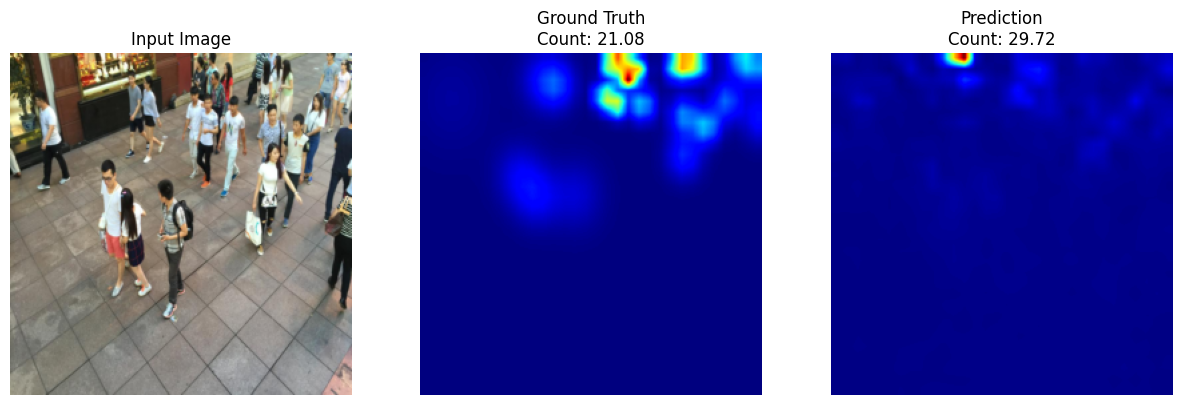

In [18]:
import matplotlib.pyplot as plt
import torch.nn.functional as F

model.eval()

images, density_maps = next(iter(test_loader))

images = images.to(device)
density_maps = density_maps.to(device)

with torch.no_grad():
    outputs = model(images)

# Scale GT correctly (same as evaluation)
scale = density_maps.shape[2] / outputs.shape[2]

gt_resized = F.interpolate(
    density_maps,
    size=outputs.shape[2:],
    mode='bilinear',
    align_corners=False
) * (scale * scale)

# For visualization only → upscale prediction to 256×256
pred_upsampled = F.interpolate(
    outputs,
    size=(256,256),
    mode='bilinear',
    align_corners=False
)

gt_upsampled = F.interpolate(
    gt_resized,
    size=(256,256),
    mode='bilinear',
    align_corners=False
)

# Convert to CPU
img = images[0].permute(1,2,0).cpu()
gt_map = gt_upsampled[0,0].cpu()
pred_map = pred_upsampled[0,0].cpu()

gt_count = gt_resized.sum().item()
pred_count = outputs.sum().item()

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.title("Input Image")
plt.imshow(img)
plt.axis("off")

plt.subplot(1,3,2)
plt.title(f"Ground Truth\nCount: {gt_count:.2f}")
plt.imshow(gt_map, cmap="jet")
plt.axis("off")

plt.subplot(1,3,3)
plt.title(f"Prediction\nCount: {pred_count:.2f}")
plt.imshow(pred_map, cmap="jet")
plt.axis("off")

plt.show()